##### Lets assume the above table is what the HR team of a company uses to determine what salary to offer to a new employee. For our project, let's take an example that an employee has applied for the role of a Regional Manager and has already worked as a Regional Manager for 2 years. So based on the table above - he falls between level 6 and level 7 - Lets say he falls under level 6.5 We want to build a model to predict what salary we should offer this new employee.
#### Build a Polynomial Regrssion model by performing EDA and do necessary transformations and select the best model using Python.
##### Prediction  -  Predict what salary we should offer this new employee.
Dataset Name - Position_Salaries.csv


In [1]:
## Importing the necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
## load the dataset

data = pd.read_csv("D:/TopMentor_DS_course/Polynomial Assignment/Position_Salaries.csv")

In [3]:
## preview the dataset
data.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [4]:
## Feature Selection

X = data[['Level']]   # Independent variable
y = data['Salary']   # Dependent variable

In [5]:
X.shape, y.shape

((10, 1), (10,))

### Linear Regression

In [6]:
## Build Linear Regression

model = LinearRegression()
model.fit(X,y)
print("Model Training Completed")

Model Training Completed


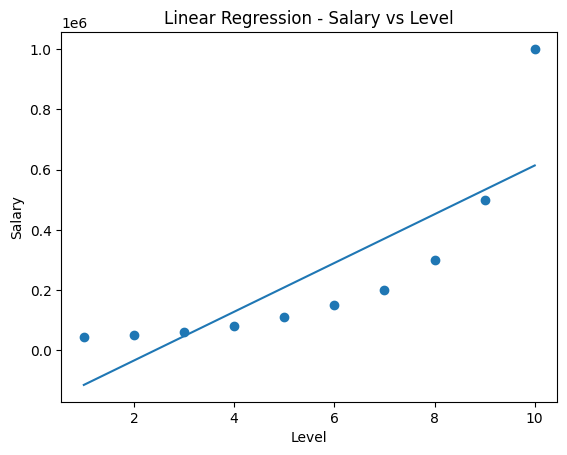

In [7]:
## Visualize Linear Regression

plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Linear Regression - Salary vs Level")
plt.savefig("D:/TopMentor_DS_course/Polynomial Assignment/Graphs/lin_reg_scatter.png")
plt.show()

#### 🔍 Observation

Straight line ❌

Salary growth is clearly curved

Underfitting problem

In [8]:
## Predict Salary for Level 6.5 (Linear)

lin_salary = model.predict([[6.5]])
lin_salary

C:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([330378.78787879])

In [9]:
data

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


### Polynomial Regression

##### Why Polynomial?

Salary increases exponentially with seniority, not linearly.

In [10]:
## Create Polynomial Features

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

In [11]:
## Train Polynomial Regression Model

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
print("Model Training Completed")

Model Training Completed


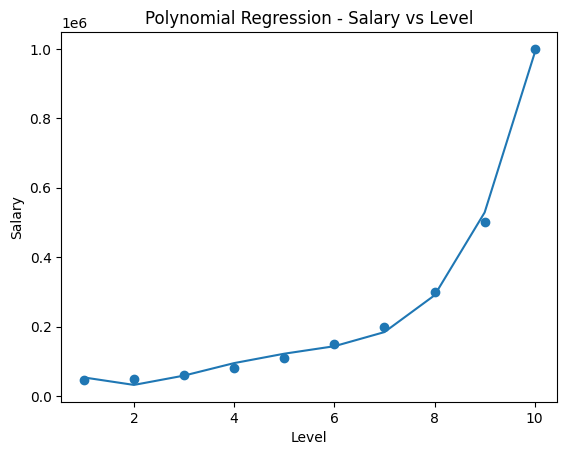

In [12]:
plt.scatter(X, y)
plt.plot(X, poly_reg.predict(X_poly))
plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression - Salary vs Level")
plt.savefig("D:/TopMentor_DS_course/Polynomial Assignment/Graphs/Poly_reg_scatter.png")
plt.show()

In [13]:
## Predict Salary for Level 6.5 (Polynomial)

poly_salary = poly_reg.predict(poly.transform([[6.5]]))
poly_salary

C:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([158862.4526515])

### Model Diagnostics & Evaluation

We’ll evaluate both models using:

R² Score → Accuracy

RMSE → Error

In [14]:
from sklearn.metrics import r2_score, mean_squared_error
from math import sqrt


#### Linear Regression Metrics

In [15]:
y_pred_lin = model.predict(X)

r2_lin = r2_score(y, y_pred_lin)
rmse_lin = sqrt(mean_squared_error(y, y_pred_lin))

r2_lin, rmse_lin

(0.6690412331929895, 163388.73519272613)

#### Polynomial Regression Metrics

In [16]:
y_pred_poly = poly_reg.predict(X_poly)

r2_poly = r2_score(y, y_pred_poly)
rmse_poly = sqrt(mean_squared_error(y, y_pred_poly))

r2_poly, rmse_poly

(0.9973922891706614, 14503.23490962701)

In [17]:
print("Predicted Salary (Polynomial Regression):", round(poly_salary[0],2))


Predicted Salary (Polynomial Regression): 158862.45


#### ✅ Final Business Conclusion

Linear Regression is not suitable for this dataset due to non-linear salary growth

Polynomial Regression (degree 4) captures the real pattern effectively

For Level 6.5, Polynomial Regression gives a more realistic salary offer

HR should rely on Polynomial Regression predictions for fair compensation